In [1]:
import numpy as np
import matplotlib.pyplot as plt

Say we have some method for finding where a particle is located. Perhaps we have an image like this, where we need to find specific structures, so the colormap of the data doesnt describe the density of the specific particle. 

 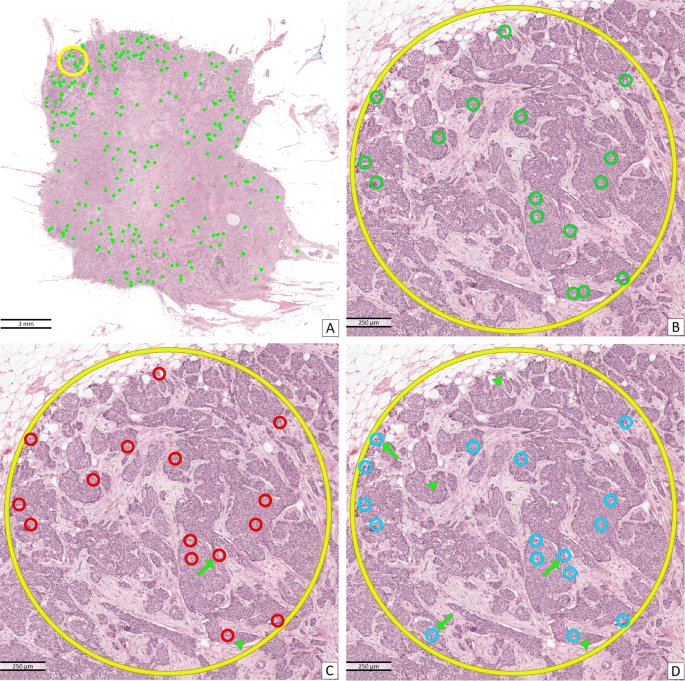

 I write a short script, which generates an area at a random location, with a random size. We can then count how many points are inside, to calculate the density at that location. If we do this for many particles, we get a nice heatmap. 

First lets generate some sample data for developing the script. Here we will create target particles of interest in a gaussian around random locations. We will create many more noise particles distributed in gaussians around other random locations. 

This should simulate similair behavior of targets and noise. They are all stuff happening around foci. 

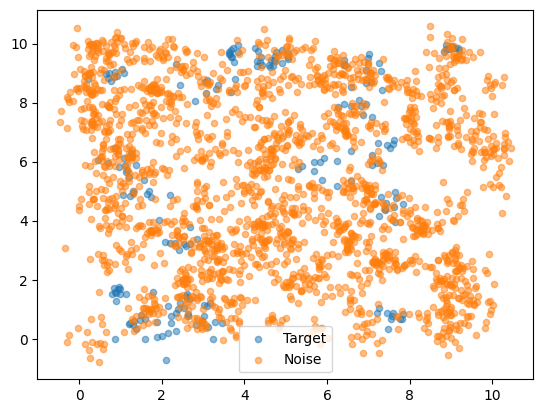

In [2]:
# Function for generating centers and widths for Gaussian distributions
def generate_centers_and_widths(N_centers, x_lim, y_lim):
    centers_x = np.random.rand(N_centers) * (x_lim[1] - x_lim[0]) + x_lim[0]
    centers_y = np.random.rand(N_centers) * (y_lim[1] - y_lim[0]) + y_lim[0]
    centers = np.column_stack((centers_x, centers_y))

    widths_x = np.random.rand(N_centers) * (x_lim[1] - x_lim[0]) / 30 + 0.1
    widths_y = widths_x * (np.random.rand(N_centers) + 0.5)
    widths = np.column_stack((widths_x, widths_y))

    return centers, widths

# Function for generating gaussian points, from these centers and widths
def roll_gaussian(centers, widths, N_points):
    points = []
    for center, width in zip(centers, widths):
        x = np.random.normal(center[0], width[0], N_points)
        y = np.random.normal(center[1], width[1], N_points)
        points.append(np.column_stack((x, y)))
    return np.vstack(points)

# Setup centers and widths
N_targets = 20
N_noise = 200
x_lim = (0, 10)
y_lim = (0, 10)
centers_target, widths_target = generate_centers_and_widths(N_targets, x_lim, y_lim)
centers_noise, widths_noise = generate_centers_and_widths(N_noise, x_lim, y_lim)

# Generate points and plot
N_points = 10
points_target = roll_gaussian(centers_target, widths_target, N_points=N_points)
points_noise = roll_gaussian(centers_noise, widths_noise, N_points=N_points)
plt.scatter(points_target[:, 0], points_target[:, 1], s=20, alpha = 0.5, label='Target')
plt.scatter(points_noise[:, 0], points_noise[:, 1], s=20, alpha = 0.5, label='Noise')
plt.legend()


We note from the graph above, that we can eyeball where target stuff is happening, but its difficult to quantify the density and distinguish it from the noise.

Now we generate some squares of random size around the field, count how many targets are inside, and estimate the density of targets within each square. 

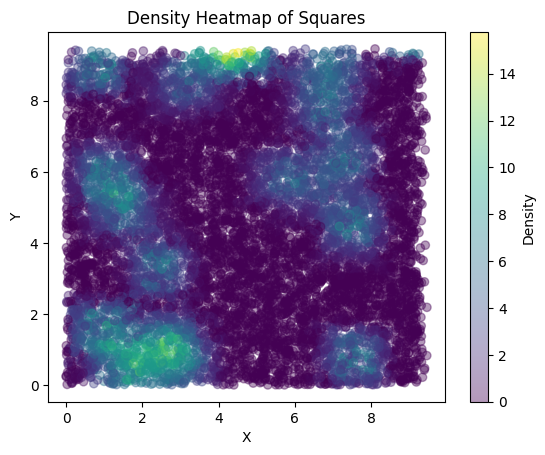

In [3]:
def generate_square():
    length = np.random.rand() * (x_lim[1] - x_lim[0]) / 10 + 1
    center = np.array([
        np.random.rand() * (x_lim[1] - x_lim[0]  - length/2) + x_lim[0],
        np.random.rand() * (y_lim[1] - y_lim[0]  - length/2) + y_lim[0]
    ])
    area = length ** 2
    return center, length, area

def is_inside_square(point, center, length):
    return (center[0] - length/2 <= point[0] <= center[0] + length/2) and \
           (center[1] - length/2 <= point[1] <= center[1] + length/2)

def count_points_inside_square(points, center, length):
    return np.sum([is_inside_square(point, center, length) for point in points])

def get_density(points_inside, area):
    return points_inside / area

# Setup field
N_squares = 10000
density_field = np.zeros((N_squares, 3))

# Generate squares
for N in range(N_squares):
    center, length, area = generate_square()
    points_inside = count_points_inside_square(points_target, center, length)
    density = get_density(points_inside, area)
    density_field[N] = np.array([*center, density])

# Lets do a heatmap
import matplotlib.pyplot as plt

plt.scatter(density_field[:, 0], density_field[:, 1], c=density_field[:, 2], alpha = 0.4, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Density Heatmap of Squares')
plt.show()

This gives a cleare picture, effectively sorting out the noise. 

Lets make a code that snaps that to the nearest grid point.

[[ 0.   0. ]
 [ 0.5  0. ]
 [ 1.   0. ]
 ...
 [18.5 19.5]
 [19.  19.5]
 [19.5 19.5]]


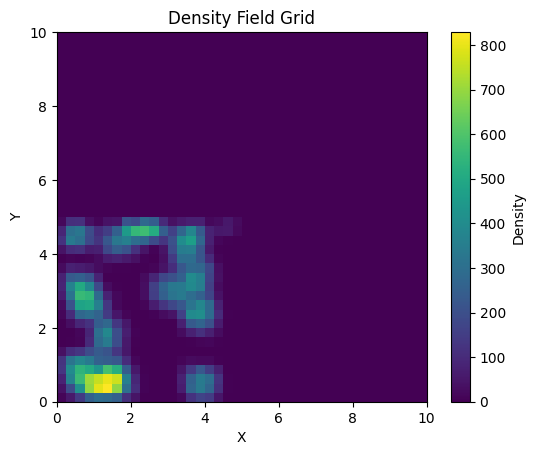

In [ ]:
#Mesh properties
resolution = 0.5
area = (2*resolution)**2

# Setup gridmesh

x_grid = np.arange(x_lim[0], x_lim[1]/resolution, resolution)
y_grid = np.arange(y_lim[0], y_lim[1]/resolution, resolution)
X, Y = np.meshgrid(x_grid, y_grid)

density_field_grid = np.zeros((len(y_grid), len(x_grid)))

centers_mesh = np.column_stack((X.ravel(), Y.ravel()))
print(centers_mesh)

for center in centers_mesh:
    for point in density_field:
        distance = np.linalg.norm(center - point[:2])
        if distance < resolution:
            ix = int((center[0] - x_lim[0]) / resolution)
            iy = int((center[1] - y_lim[0]) / resolution)
            density_field_grid[iy, ix] += point[2]

# Plot density field grid
plt.imshow(density_field_grid, extent=(x_lim[0], x_lim[1], y_lim[0], y_lim[1]), origin='lower')
plt.colorbar(label='Density')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Density Field Grid')
plt.show()